In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/LA_dataset.csv", low_memory=False)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [2]:
print(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   dr_no           1004894 non-null  int64  
 1   date_rptd       1004894 non-null  str    
 2   date_occ        1004894 non-null  str    
 3   time_occ        1004894 non-null  int64  
 4   area            1004894 non-null  int64  
 5   area_name       1004894 non-null  str    
 6   rpt_dist_no     1004894 non-null  int64  
 7   part_1-2        1004894 non-null  int64  
 8   crm_cd          1004894 non-null  int64  
 9   crm_cd_desc     1004894 non-null  str    
 10  mocodes         853296 non-null   str    
 11  vict_age        1004894 non-null  int64  
 12  vict_sex        860263 non-null   str    
 13  vict_descent    860251 non-null   str    
 14  premis_cd       1004878 non-null  float64
 15  premis_desc     1004306 non-null  str    
 16  weapon_used_cd  327216 non-null   float64
 17  

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,...,status,status_desc,crm_cd_1,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
0,211507896,2021 Apr 11 12:00:00 AM,2020 Nov 07 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020 Oct 21 12:00:00 AM,2020 Oct 18 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024 Dec 10 12:00:00 AM,2020 Oct 30 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,2020 Dec 24 12:00:00 AM,2020 Dec 24 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,2020 Oct 03 12:00:00 AM,2020 Sep 29 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [3]:
df = df.drop_duplicates()
df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')
df = df.dropna(subset=['date_occ', 'lat', 'lon'])

df['hour'] = df['time_occ'] // 100
df['day_of_week'] = df['date_occ'].dt.dayofweek
df['month'] = df['date_occ'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

grid_size = 0.01
df['lat_grid'] = (df['lat'] // grid_size) * grid_size
df['lon_grid'] = (df['lon'] // grid_size) * grid_size

grid_counts = df.groupby(['lat_grid', 'lon_grid']).size().reset_index(name='crime_count')
features = df.groupby(['lat_grid', 'lon_grid', 'hour']).size().reset_index(name='crime_count')

C:\Users\NISHIT\AppData\Local\Temp\ipykernel_14968\3137446052.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')


C:\Users\NISHIT\AppData\Local\Temp\ipykernel_14968\2757232497.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


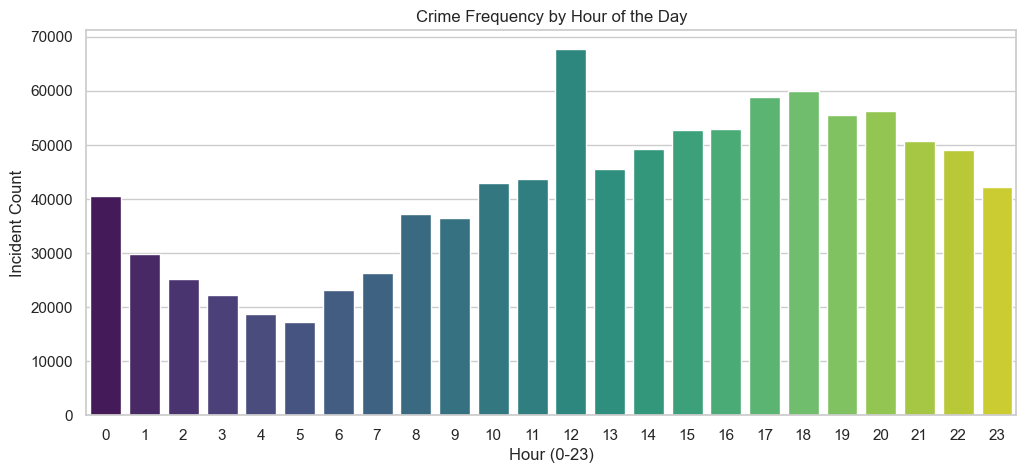

C:\Users\NISHIT\AppData\Local\Temp\ipykernel_14968\2757232497.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week', data=df, palette='coolwarm')


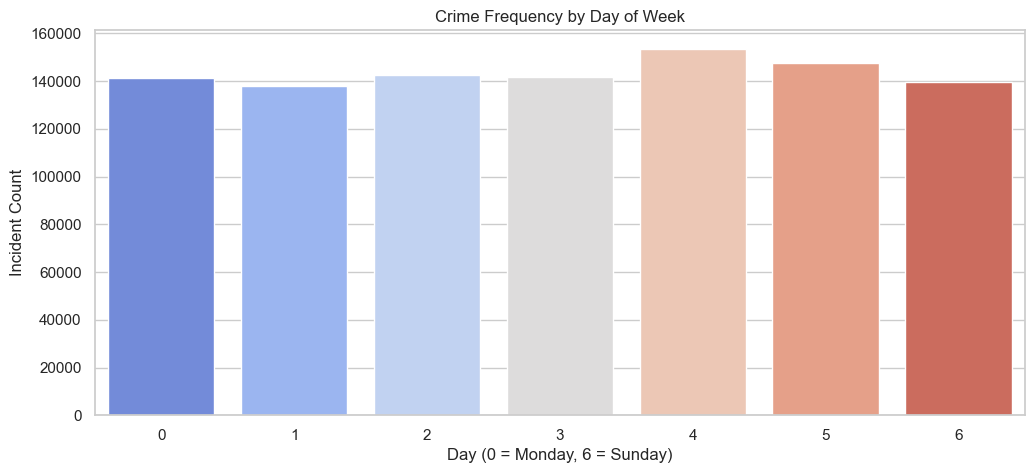

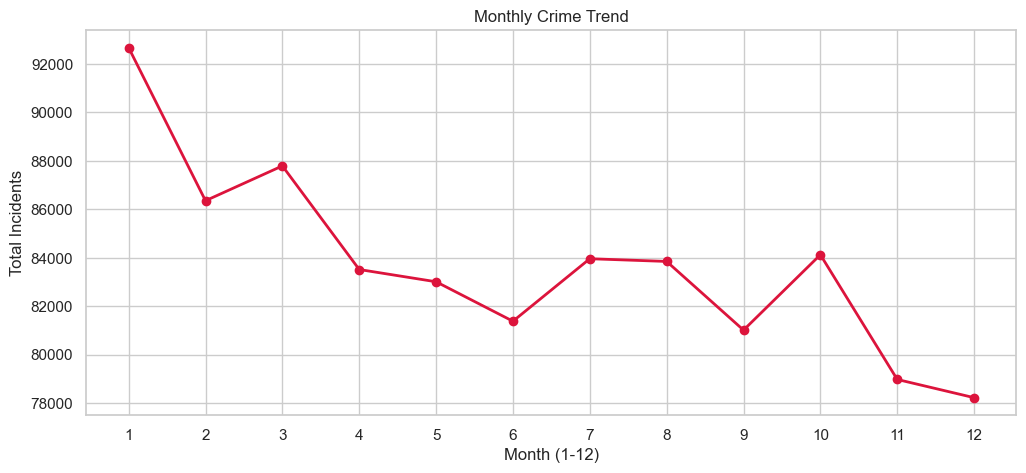

In [4]:
plt.figure(figsize=(12, 5))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title("Crime Frequency by Hour of the Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Incident Count")
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(x='day_of_week', data=df, palette='coolwarm')
plt.title("Crime Frequency by Day of Week")
plt.xlabel("Day (0 = Monday, 6 = Sunday)")
plt.ylabel("Incident Count")
plt.show()

plt.figure(figsize=(12, 5))
df.groupby('month').size().plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title("Monthly Crime Trend")
plt.xlabel("Month (1-12)")
plt.ylabel("Total Incidents")
plt.xticks(range(1, 13))
plt.show()

C:\Users\NISHIT\AppData\Local\Temp\ipykernel_14968\2972777607.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_crimes.index, x=top_crimes.values, palette='magma')


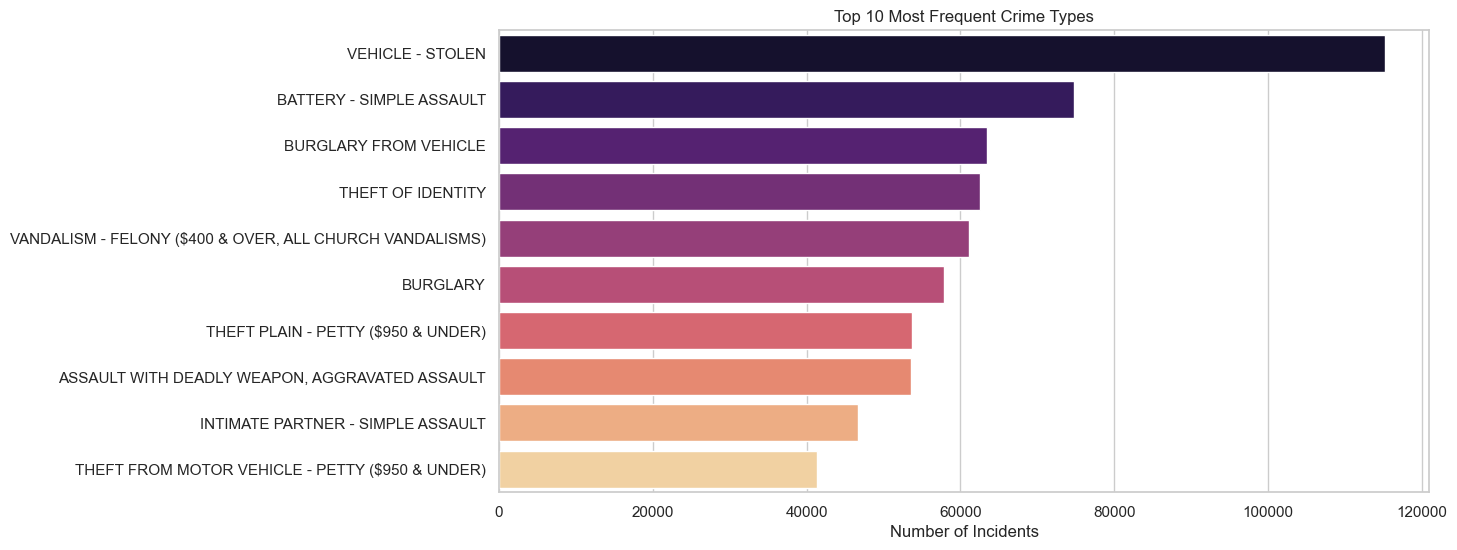

C:\Users\NISHIT\AppData\Local\Temp\ipykernel_14968\2972777607.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_premises.index, x=top_premises.values, palette='crest')


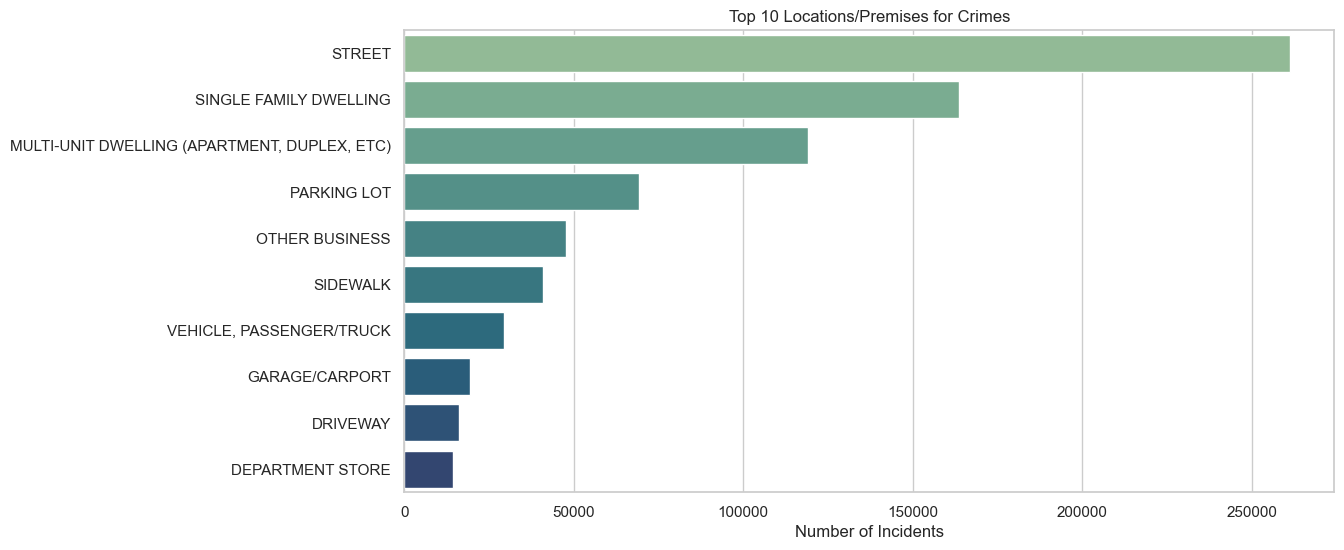

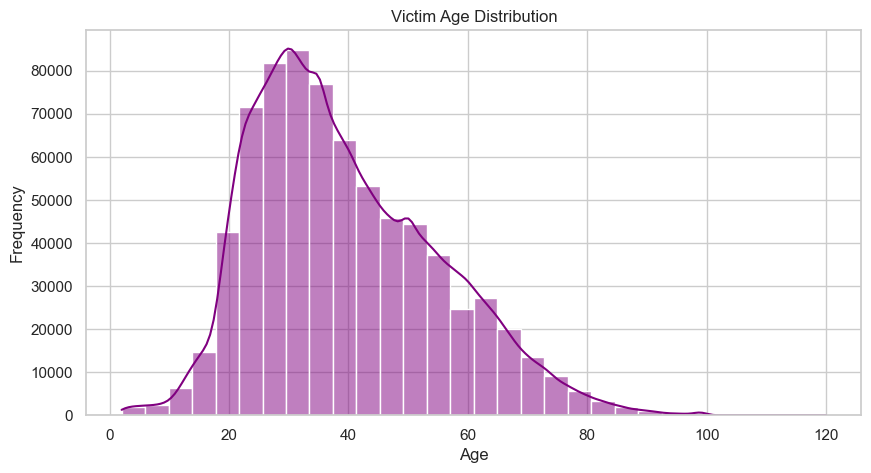

In [5]:
plt.figure(figsize=(12, 6))
top_crimes = df['crm_cd_desc'].value_counts().head(10)
sns.barplot(y=top_crimes.index, x=top_crimes.values, palette='magma')
plt.title("Top 10 Most Frequent Crime Types")
plt.xlabel("Number of Incidents")
plt.ylabel("")
plt.show()

plt.figure(figsize=(12, 6))
top_premises = df['premis_desc'].value_counts().head(10)
sns.barplot(y=top_premises.index, x=top_premises.values, palette='crest')
plt.title("Top 10 Locations/Premises for Crimes")
plt.xlabel("Number of Incidents")
plt.ylabel("")
plt.show()

plt.figure(figsize=(10, 5))
valid_ages = df[df['vict_age'] > 0]
sns.histplot(valid_ages['vict_age'], bins=30, kde=True, color='purple')
plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [6]:
fig = px.density_map(
    df,
    lat='lat',
    lon='lon',
    radius=10,
    zoom=9,
    map_style="open-street-map",
    title="Los Angeles Crime Density Hotspot Map"
)
fig.show("browser")

In [7]:
top_grids = grid_counts.sort_values(by='crime_count', ascending=False).head(10)
print("Top 10 High-Risk Grid Cells:\\n", top_grids)

numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

df.to_csv("../data/cleaned_crime_data.csv", index=False)
features.to_csv("../data/model_features.csv", index=False)

Top 10 High-Risk Grid Cells:\n      lat_grid  lon_grid  crime_count
393     34.04   -118.26        15985
394     34.04   -118.25        13132
392     34.04   -118.27         9540
428     34.05   -118.28         7957
429     34.05   -118.27         6717
596     34.10   -118.34         6271
459     34.06   -118.29         5356
458     34.06   -118.30         5238
431     34.05   -118.25         5190
430     34.05   -118.26         5052
